Based on the guide for feature engineering here: https://xgboosting.com/feature-engineering/

Two types of feature engineering seem relevant:
- binning certain numerical variables.
- create new features by combining existing ones.

In [1]:
import pandas as pd
import numpy as np
import glob

In [2]:
files = glob.glob("../data/*/*")
files

['../data/s5e6/test.csv',
 '../data/s5e6/previous_competition.csv',
 '../data/s5e6/train.csv',
 '../data/s5e6/sample_submission.csv']

In [3]:
train_df = pd.read_csv(files[2])
test_df = pd.read_csv(files[0])
original_df = pd.read_csv(files[1])
submission_df = pd.read_csv(files[3])

In [4]:
target_feature = list(train_df.columns)[-1]
numerical_features = [x for x in train_df.describe().columns if x != "id"]
categorical_features = [x for x in train_df.columns if x not in numerical_features and x != "id" and x != target_feature]
numerical_features, categorical_features

(['Temparature',
  'Humidity',
  'Moisture',
  'Nitrogen',
  'Potassium',
  'Phosphorous'],
 ['Soil Type', 'Crop Type'])

In [5]:
train_df = train_df.drop(columns = ["id"])
train_df = pd.concat([train_df, original_df], ignore_index = True)
train_df.tail(10)

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
849990,36,59,32,Sandy,Wheat,34,17,17,28-28
849991,26,54,30,Black,Millets,35,14,0,20-20
849992,27,50,47,Black,Paddy,22,7,28,20-20
849993,36,68,38,Sandy,Paddy,19,1,4,20-20
849994,32,51,45,Clayey,Paddy,27,8,2,20-20
849995,32,71,61,Black,Tobacco,23,1,25,20-20
849996,35,72,47,Loamy,Millets,38,1,32,17-17-17
849997,28,50,61,Sandy,Maize,10,11,14,14-35-14
849998,29,57,63,Loamy,Ground Nuts,7,10,4,DAP
849999,25,72,42,Sandy,Wheat,38,2,6,17-17-17


#### Approach
`also inspired from (here)[https://medium.com/@bijit211987/10-advanced-feature-engineering-methods-46b63a1ee92e]`

- Create these features: 
    - binning wherever required and obvious.
    - based on [this](https://www.google.com/search?q=what+is+the+relation+between+humidity+and+temperature&oq=what+is+the+relation+between+humidity+&gs_lcrp=EgZjaHJvbWUqBwgAEAAYgAQyBwgAEAAYgAQyBwgBEAAYgAQyBwgCEAAYgAQyBwgDEAAYgAQyBggEEEUYOTIHCAUQABiABDIHCAYQABiABDIICAcQABgWGB4yCAgIEAAYFhgeMggICRAAGBYYHtIBCDY5NTRqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8) - make a feature adding normalized temp. and humidity & binning them (`inverse relationship`)
    - based on [this](https://www.google.com/search?q=what+is+humidity%27s+relation+to+moisture&oq=what+is+humidity%27s+relation+to+moisture&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIICAEQABgWGB4yDQgCEAAYhgMYgAQYigUyDQgDEAAYhgMYgAQYigUyCggEEAAYgAQYogQyCggFEAAYogQYiQUyCggGEAAYgAQYogQyBwgHEAAY7wXSAQg3NzM2ajBqN6gCALACAA&sourceid=chrome&ie=UTF-8) - dividing moisture in air (humidity) BY moisture in soil (`relative moisture`)
    - for each crop type, create a continuous variable that captures relationship between CropType and each of nitrogen, potassium and phosphorous using [this](https://chatgpt.com/share/6852c4e0-83c0-8003-959e-e2b9700dbff7)


- Get feature importance of each of these features with the RandomForest method described earlier.

### 1. Binning numerical features to make categorical ones.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def univariate_feature_plots(feature_name):
    plt.figure(figsize = (12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[feature_name], kde = True, bins = 30)
    plt.title(f"Histogram of {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x = train_df[feature_name])
    plt.title(f"Box plot of {feature_name}")

    plt.tight_layout()
    plt.show()

    print(f"Statistics: for {feature_name}", end = '\n')
    print(f"Skewness: {train_df[feature_name].skew():.2f}")
    print(f"Number of missing values: {train_df[train_df[feature_name].isnull()].shape[0]}")

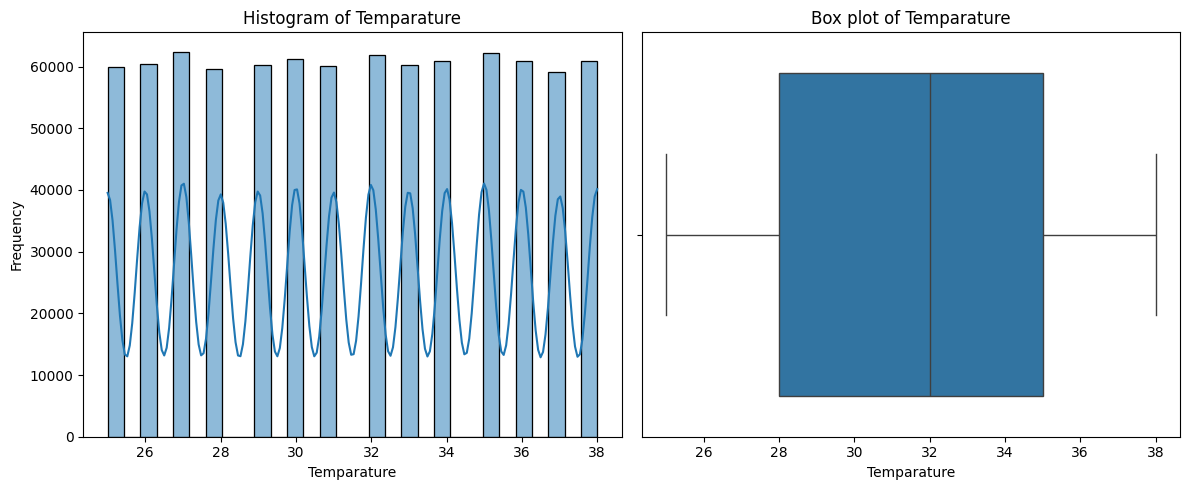

Statistics: for Temparature
Skewness: -0.00
Number of missing values: 0


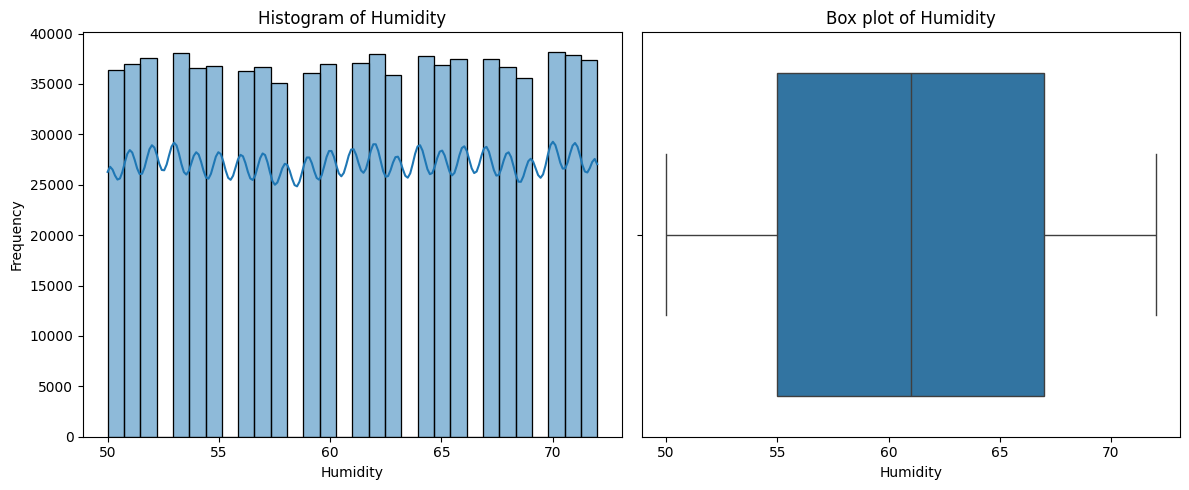

Statistics: for Humidity
Skewness: -0.01
Number of missing values: 0


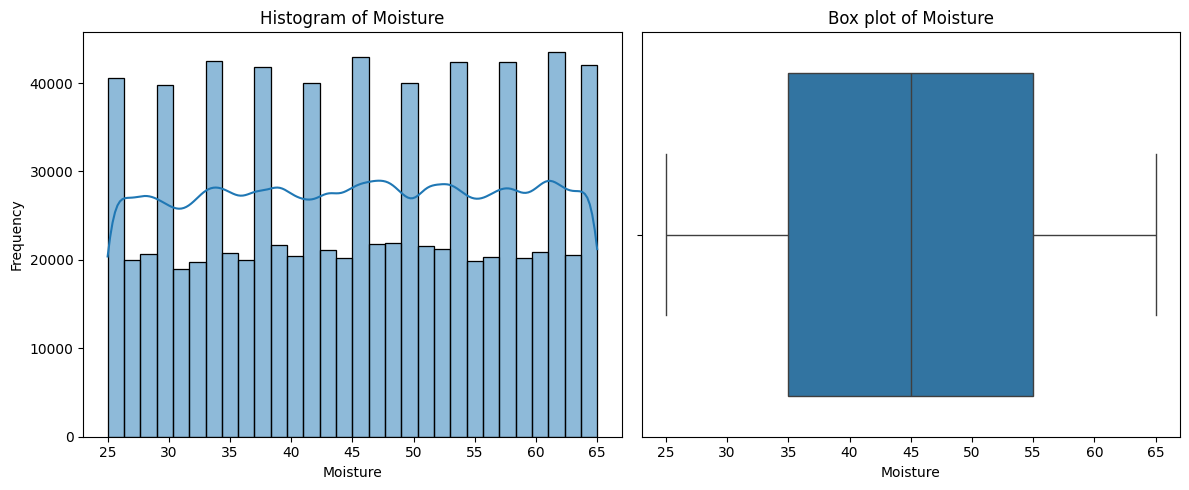

Statistics: for Moisture
Skewness: -0.02
Number of missing values: 0


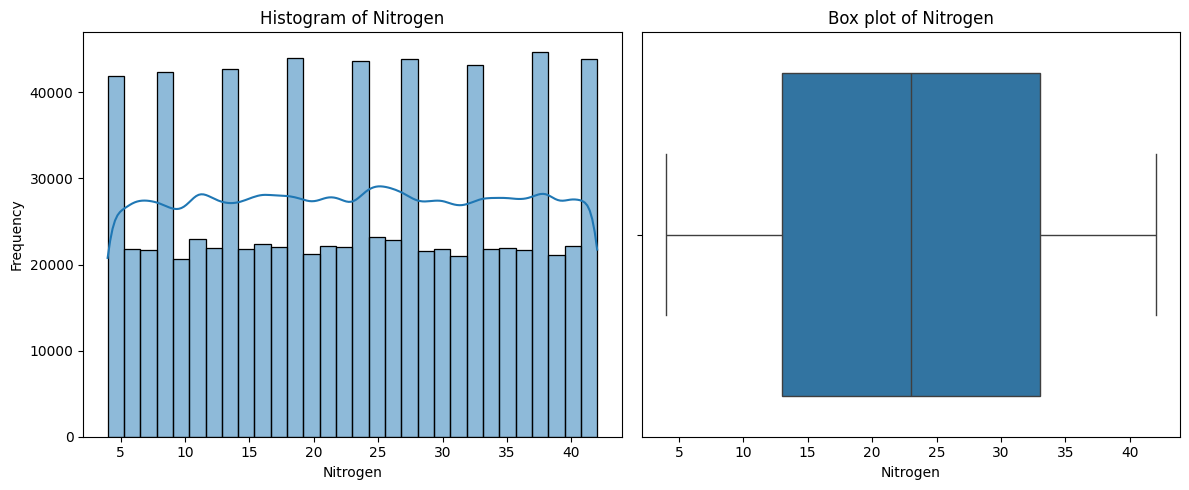

Statistics: for Nitrogen
Skewness: -0.01
Number of missing values: 0


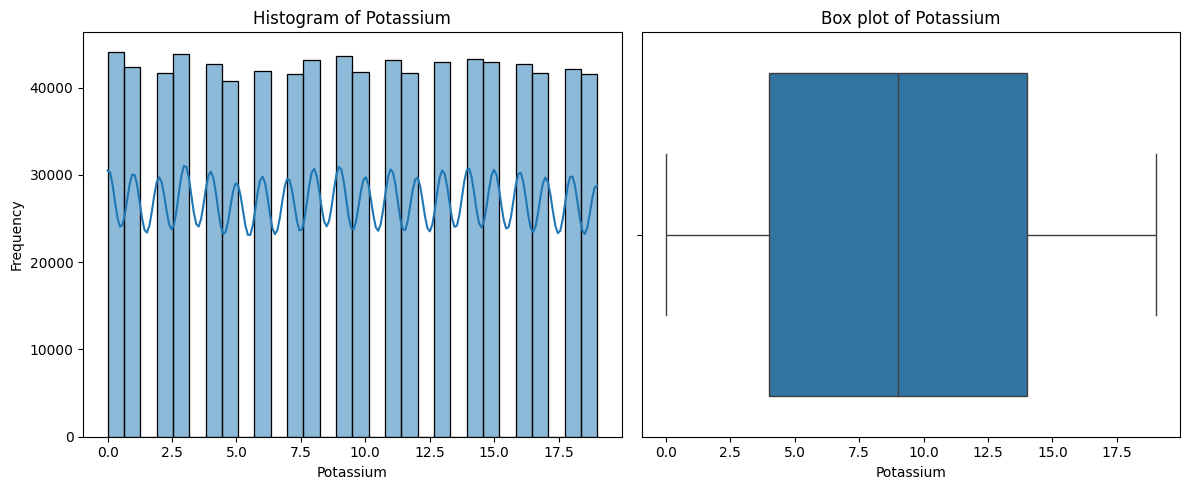

Statistics: for Potassium
Skewness: -0.00
Number of missing values: 0


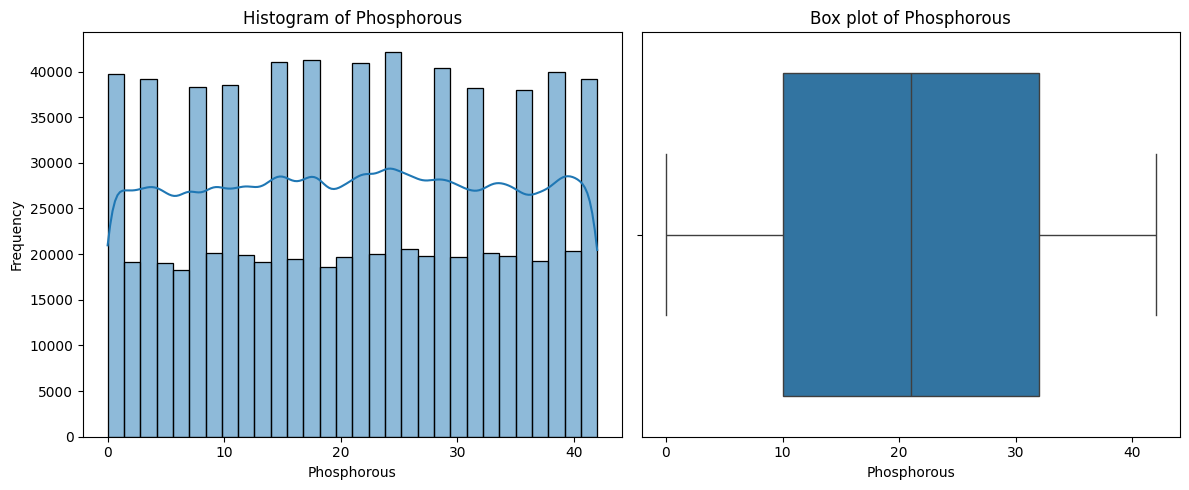

Statistics: for Phosphorous
Skewness: -0.01
Number of missing values: 0


In [7]:
for feature in numerical_features:
    univariate_feature_plots(feature)

Decision FOR checking binning:
- Not that important for most features, seems like since none of the features have any serious outliers.
- To improve performance on low performing features from earlier -> temperature, humidity - we consider binning -> Quantile binning for fixed number of categories.

In [8]:
numerical_features

['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

In [9]:
temp_feature = numerical_features[0]
humidity_feature = numerical_features[1]
train_df['Temperature Binned'] = pd.qcut(train_df[temp_feature], q = 4, labels = ['Low', 'Medium', 'High', 'Very High'])
train_df['Humidity Binned'] = pd.qcut(train_df[humidity_feature], q = 4, labels = ['Low', 'Medium', 'High', 'Very High'])

### 2. Adding normalized temperature and humidity together (And then binning that)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
normalized = scaler.fit_transform(train_df[[temp_feature, humidity_feature]])

In [12]:
train_df['Temperature Humidity Index'] = normalized[:, 0] + normalized[:, 1] 

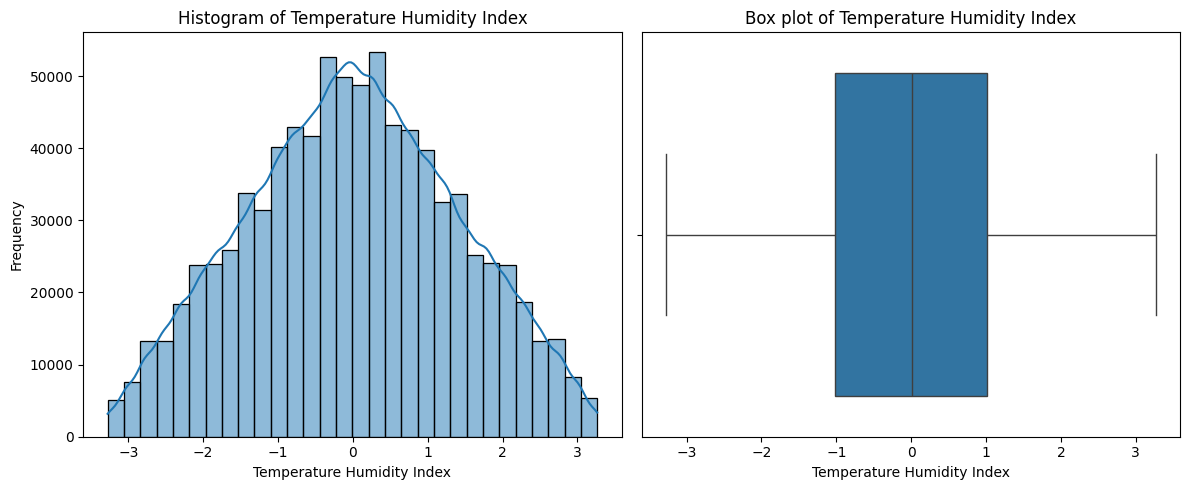

Statistics: for Temperature Humidity Index
Skewness: 0.00
Number of missing values: 0


In [13]:
univariate_feature_plots('Temperature Humidity Index')

In [14]:
### intermediate results.
# train_df.head()

#### 3. divide the humidity by moisture in soil & then bin that as well.

In [15]:
numerical_features

['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

In [16]:
moisture_feature = numerical_features[2]

In [17]:
scaler = StandardScaler()
normalized = scaler.fit_transform(train_df[[humidity_feature, moisture_feature]])
epsilon = 1e-6
train_df['Humidity Moisture Ratio'] = train_df[humidity_feature] / (train_df[moisture_feature] + epsilon)

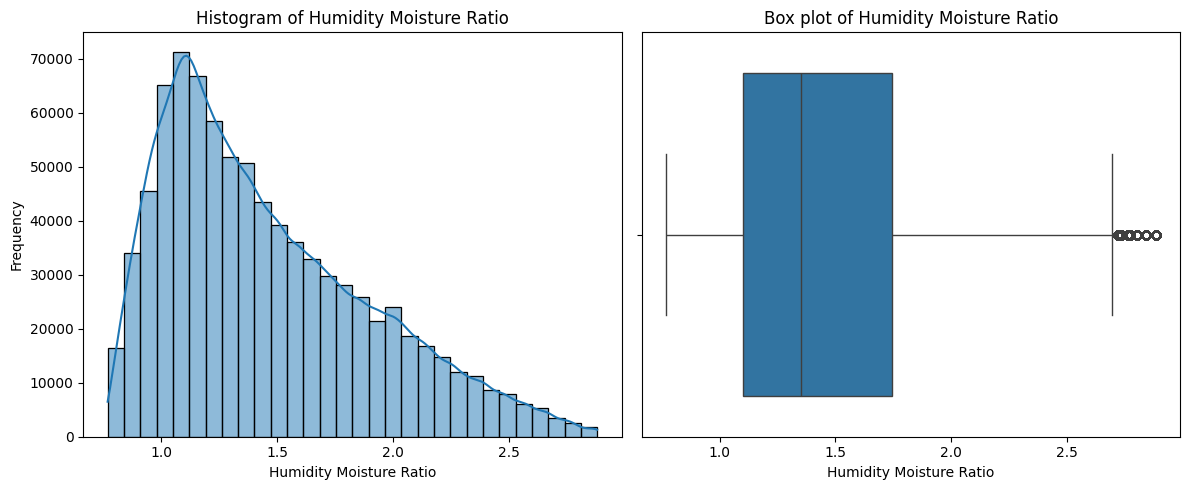

Statistics: for Humidity Moisture Ratio
Skewness: 0.80
Number of missing values: 0


In [18]:
univariate_feature_plots('Humidity Moisture Ratio')

In [20]:
def plot_distribution_of_categorical_feature(feature_name):
    counts = train_df[feature_name].value_counts() ## 
    plt.figure(figsize = (10, 10))
    plt.subplot(2, 1, 1)
    plt.pie(counts, labels = counts.index, autopct = "%1.2f%%")
    plt.title(f"Distribution of {feature_name}")
    plt.axis("equal")

    plt.subplot(2, 1, 2)
    sns.countplot(x = feature_name, data = train_df)
    plt.show()

    print(f"Number of unique {feature_name} values: {counts.shape[0]}")
    print(f"Missing Values in {feature_name}: {train_df[train_df[feature_name].isnull()].shape[0]}")

In [21]:
## intermediate results.
train_df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temperature Binned,Humidity Binned,Temperature Humidity Index,Humidity Moisture Ratio
0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,Very High,Very High,2.714461,1.944444
1,27,69,65,Sandy,Millets,30,6,18,28-28,Low,Very High,0.079514,1.061538
2,29,63,32,Sandy,Millets,24,12,16,17-17-17,Medium,High,-0.326088,1.968750
3,35,62,54,Sandy,Barley,39,12,4,10-26-26,High,High,1.014212,1.148148
4,35,58,43,Red,Paddy,37,2,16,DAP,High,Medium,0.412540,1.348837


#### Decision:
- since there are a few outliers for temperature humidity index, we would need to either i) normalize them OR ii) cap the outliers to some number OR iii) bin the values in some way to normalize the training => let's see the results for feature importance to make that decision.

### 4. Combine CropType and minerals to create new numerical features.

In [22]:
numerical_features

['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

In [23]:
categorical_features

['Soil Type', 'Crop Type']

In [27]:
for feature in numerical_features[3:]:
    print(f"Distribution of feature {feature} by CropType")
    print(train_df.groupby(categorical_features[1])[feature].describe())
    print("\n\n")

Distribution of feature Nitrogen by CropType
               count       mean        std  min   25%   50%   75%   max
Crop Type                                                              
Barley       74086.0  23.218084  11.026722  4.0  14.0  23.0  32.0  42.0
Cotton       78408.0  23.101559  11.269115  4.0  13.0  23.0  33.0  42.0
Ground Nuts  69790.0  23.004714  11.135339  4.0  13.0  23.0  33.0  42.0
Maize        71582.0  22.996005  11.142096  4.0  13.0  23.0  32.0  42.0
Millets      74445.0  23.224461  11.265070  4.0  13.0  23.0  33.0  42.0
Oil seeds    73280.0  22.898881  11.237688  4.0  13.0  23.0  33.0  42.0
Paddy        94857.0  22.910929  11.330698  4.0  13.0  23.0  33.0  42.0
Pulses       87252.0  23.046612  11.224901  4.0  13.0  23.0  33.0  42.0
Sugarcane    73536.0  23.005127  11.170110  4.0  13.0  23.0  33.0  42.0
Tobacco      77224.0  23.252059  11.375005  4.0  13.0  24.0  33.0  42.0
Wheat        75540.0  23.266217  11.180579  4.0  14.0  23.0  33.0  42.0



Distribution of 

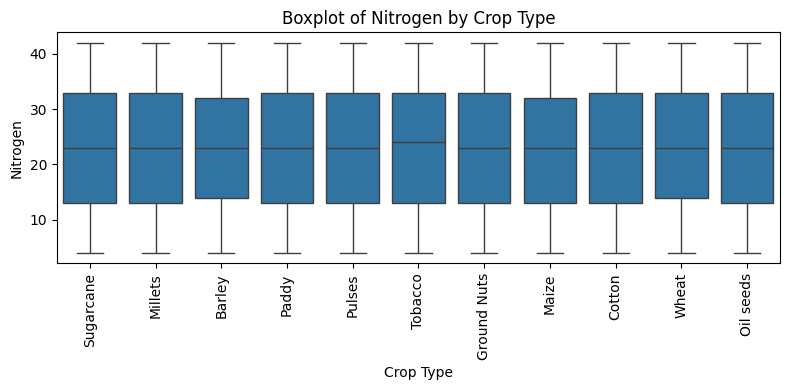

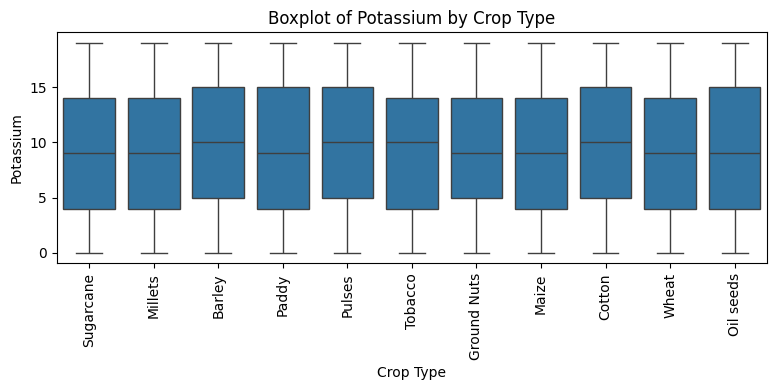

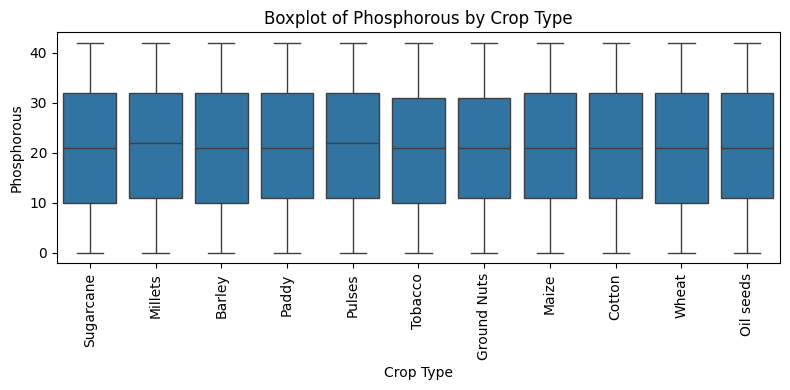

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in numerical_features[3:]:
    plt.figure(figsize = (8, 4))  
    sns.boxplot(x = categorical_features[1], y = feature, data = train_df, )  
    plt.xticks(rotation = 90)
    plt.title(f"Boxplot of {feature} by Crop Type")
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

m_scaler = MinMaxScaler()
normalized_mineral_vals = m_scaler.fit_transform(train_df[numerical_features[3:]])

In [33]:
len(normalized_mineral_vals), len(normalized_mineral_vals[0])

(850000, 3)

In [34]:
nmv = normalized_mineral_vals ## simple name.

In [35]:
## adding the normalized columns into a new column.
train_df['Summarized Mineral Values'] = nmv[:, 0] + nmv[:, 1] + nmv[:, 2]
train_df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temperature Binned,Humidity Binned,Temperature Humidity Index,Humidity Moisture Ratio,Summarized Mineral Values
0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,Very High,Very High,2.714461,1.944444,1.171679
1,27,69,65,Sandy,Millets,30,6,18,28-28,Low,Very High,0.079514,1.061538,1.428571
2,29,63,32,Sandy,Millets,24,12,16,17-17-17,Medium,High,-0.326088,1.968750,1.538847
3,35,62,54,Sandy,Barley,39,12,4,10-26-26,High,High,1.014212,1.148148,1.647870
4,35,58,43,Red,Paddy,37,2,16,DAP,High,Medium,0.412540,1.348837,1.354637


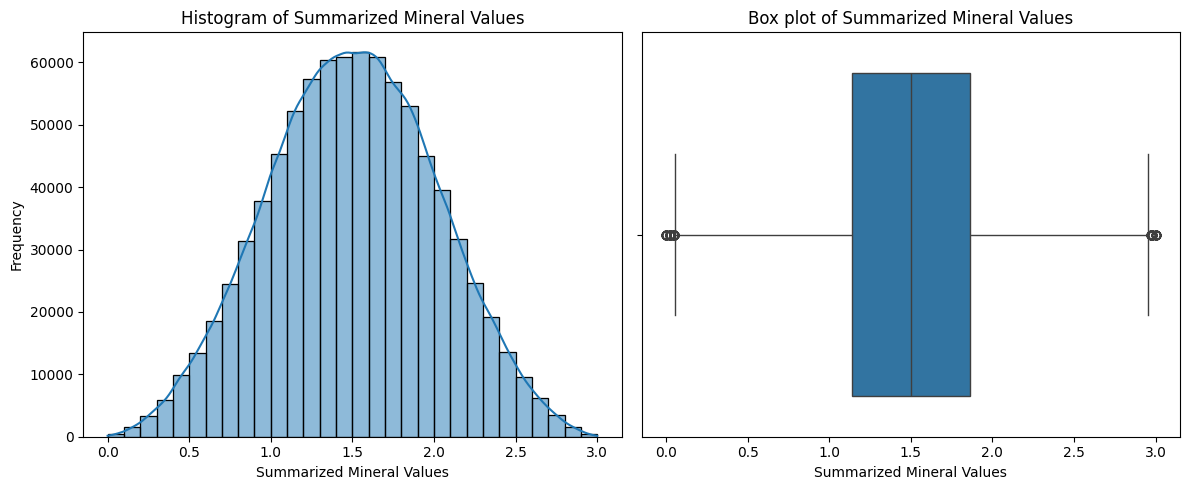

Statistics: for Summarized Mineral Values
Skewness: -0.00
Number of missing values: 0


In [36]:
univariate_feature_plots('Summarized Mineral Values')

In [37]:
def clip_numerical_values(numerical_feature):
    q1 = train_df[numerical_feature].quantile(0.25)
    q3 = train_df[numerical_feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    train_df[f"{numerical_feature}_clipped"] = train_df[numerical_feature].clip(lower = lower_bound, upper = upper_bound, )

In [38]:
train_df.columns

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name',
       'Temperature Binned', 'Humidity Binned', 'Temperature Humidity Index',
       'Humidity Moisture Ratio', 'Summarized Mineral Values'],
      dtype='object')

In [39]:
tbc_features = list(train_df.columns)[-2:]
tbc_features

['Humidity Moisture Ratio', 'Summarized Mineral Values']

In [40]:
for feature in tbc_features:
    clip_numerical_values(feature)

In [41]:
train_df.columns

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name',
       'Temperature Binned', 'Humidity Binned', 'Temperature Humidity Index',
       'Humidity Moisture Ratio', 'Summarized Mineral Values',
       'Humidity Moisture Ratio_clipped', 'Summarized Mineral Values_clipped'],
      dtype='object')

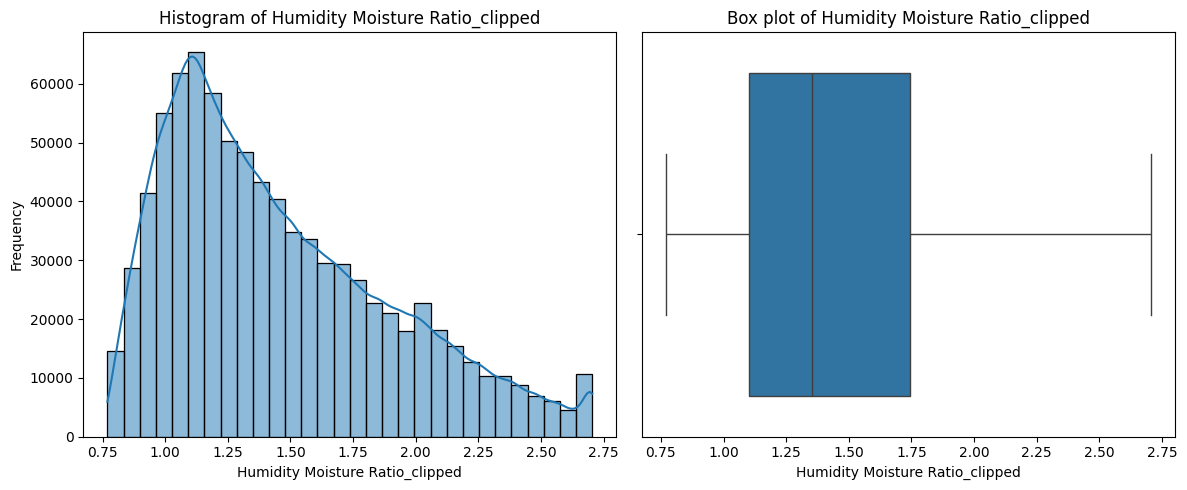

Statistics: for Humidity Moisture Ratio_clipped
Skewness: 0.78
Number of missing values: 0


In [42]:
univariate_feature_plots('Humidity Moisture Ratio_clipped')

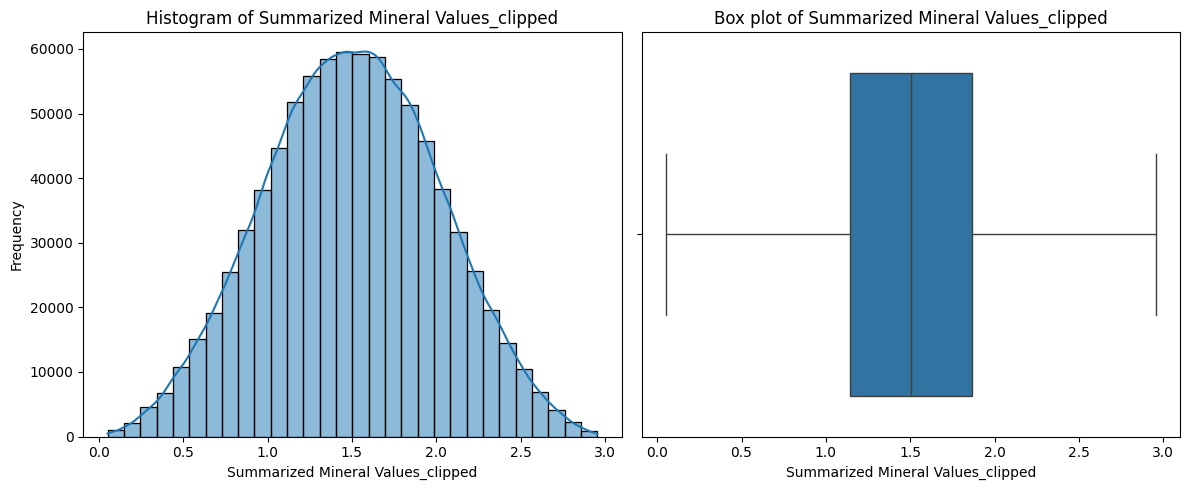

Statistics: for Summarized Mineral Values_clipped
Skewness: -0.00
Number of missing values: 0


In [43]:
univariate_feature_plots('Summarized Mineral Values_clipped')

In [45]:
### drop certain columns. -> tbc_features && the first two numerical_features.
nc_features = list(train_df.columns)[:2]
nc_features

['Temparature', 'Humidity']

In [46]:
trimmed_train_df = train_df.drop(columns = [*nc_features, *tbc_features])
trimmed_train_df.head()

,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temperature Binned,Humidity Binned,Temperature Humidity Index,Humidity Moisture Ratio_clipped,Summarized Mineral Values_clipped
0,36,Clayey,Sugarcane,36,4,5,28-28,Very High,Very High,2.714461,1.944444,1.171679
1,65,Sandy,Millets,30,6,18,28-28,Low,Very High,0.079514,1.061538,1.428571
2,32,Sandy,Millets,24,12,16,17-17-17,Medium,High,-0.326088,1.968750,1.538847
3,54,Sandy,Barley,39,12,4,10-26-26,High,High,1.014212,1.148148,1.647870
4,43,Red,Paddy,37,2,16,DAP,High,Medium,0.412540,1.348837,1.354637


#### s1: use a simple xgboost model and feature importance to see the new trends (also check if accuracy has improved from earlier.)

In [47]:
numerical_features = [x for x in trimmed_train_df.describe().columns if x != "id"]
categorical_features = [x for x in trimmed_train_df.columns if x not in numerical_features and x != "id" and x != target_feature]
numerical_features, categorical_features

(['Moisture',
  'Nitrogen',
  'Potassium',
  'Phosphorous',
  'Temperature Humidity Index',
  'Humidity Moisture Ratio_clipped',
  'Summarized Mineral Values_clipped'],
 ['Soil Type', 'Crop Type', 'Temperature Binned', 'Humidity Binned'])

+++++ important note ++++

since we are just interested in feature importance, we have normalized certain features on the whole set, when doing model selection and evaluation, we have to be careful about doing it only on the training set.

+++++ see this +++++

In [49]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

oe = OrdinalEncoder()
trimmed_train_df[categorical_features] = oe.fit_transform(trimmed_train_df[categorical_features])
for col in categorical_features:
    trimmed_train_df[col] = trimmed_train_df[col].astype("category")

## transformation of the label.
le = LabelEncoder()
trimmed_train_df[target_feature] = le.fit_transform(trimmed_train_df[target_feature])
trimmed_train_df.head()

,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temperature Binned,Humidity Binned,Temperature Humidity Index,Humidity Moisture Ratio_clipped,Summarized Mineral Values_clipped
0,36,1.0,8.0,36,4,5,4,3.0,3.0,2.714461,1.944444,1.171679
1,65,4.0,4.0,30,6,18,4,1.0,3.0,0.079514,1.061538,1.428571
2,32,4.0,4.0,24,12,16,2,2.0,0.0,-0.326088,1.968750,1.538847
3,54,4.0,0.0,39,12,4,0,0.0,0.0,1.014212,1.148148,1.647870
4,43,3.0,6.0,37,2,16,5,0.0,2.0,0.412540,1.348837,1.354637


In [50]:
### reduce each numerical feature value to 1 decimal point.
for feature in numerical_features:
    trimmed_train_df[feature] = trimmed_train_df[feature].round(1)

In [51]:
trimmed_train_df.head()

,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temperature Binned,Humidity Binned,Temperature Humidity Index,Humidity Moisture Ratio_clipped,Summarized Mineral Values_clipped
0,36,1.0,8.0,36,4,5,4,3.0,3.0,2.7,1.9,1.2
1,65,4.0,4.0,30,6,18,4,1.0,3.0,0.1,1.1,1.4
2,32,4.0,4.0,24,12,16,2,2.0,0.0,-0.3,2.0,1.5
3,54,4.0,0.0,39,12,4,0,0.0,0.0,1.0,1.1,1.6
4,43,3.0,6.0,37,2,16,5,0.0,2.0,0.4,1.3,1.4


In [55]:
from sklearn.model_selection import train_test_split

full_y, full_x = trimmed_train_df[target_feature], trimmed_train_df.drop(columns = [target_feature])
train_x, test_x, train_y, test_y = train_test_split(full_x, full_y, test_size = 0.1, random_state = 42, stratify = full_y) ## use a lower test size fraction to get maximal results.

In [57]:
## settings from the designated notebook.
from xgboost import XGBClassifier
model_xg_multi = XGBClassifier(
    objective = "multi:softprob",
    num_class = len(np.unique(train_y)),
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 12,
    colsmaple_bytree = 0.467,
    early_stopping_rounds = 100,
    reg_alpha = 2.7,
    reg_lambda = 1.4,
    gamma = 0.26,
    enable_categorical = True,
    tree_method = 'hist',
    max_delta_step = 4,
    subsample = 0.86,
    random_state = 13,
    device = "cuda"
)
model_xg_multi.fit(train_x, train_y, eval_set = [(test_x, test_y)], verbose = 0)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, colsmaple_bytree=0.467, device='cuda',
              early_stopping_rounds=100, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.26, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=4,
              max_depth=12, max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, ...)

In [58]:
def predict_and_score_xgboost_multi(model):
    y_pred_probs = model.predict_proba(test_x)
    top3_probs = np.argsort(y_pred_probs, axis = 1)[:, -3:][:, ::-1]
    get_best_and_full_accuracy_xgboost(test_y, top3_probs)

    return top3_probs

def _get_score(actual, predicted):
    score = 0.0
    hits = 0
    seen = set()
    for i, pred in enumerate(predicted):
        if pred == np.int64(actual) and pred not in seen:
            hits += 1
            score += hits / (i + 1.0)
            seen.add(pred)
    
    return score ## since actual is ONE entity.


def get_best_and_full_accuracy_xgboost(ptest_y, topk_probs):
    test_yl = ptest_y.tolist()
    first_acc_l = [x for idx, x in enumerate(test_yl) if np.int64(x) == topk_probs[idx][0]]
    score_accl_l = [_get_score(x ,topk_probs[idx]) for idx, x in enumerate(test_yl)]

    print(f"First accuracy: {(len(first_acc_l) / len(test_yl)):.2f}") ## only based on the highest class.
    print(f"Score accuracy: {(np.mean(score_accl_l)):.2f}") ## based on the function defined earlier.

top3_xg_multi = predict_and_score_xgboost_multi(model_xg_multi)

First accuracy: 0.20
Score accuracy: 0.34


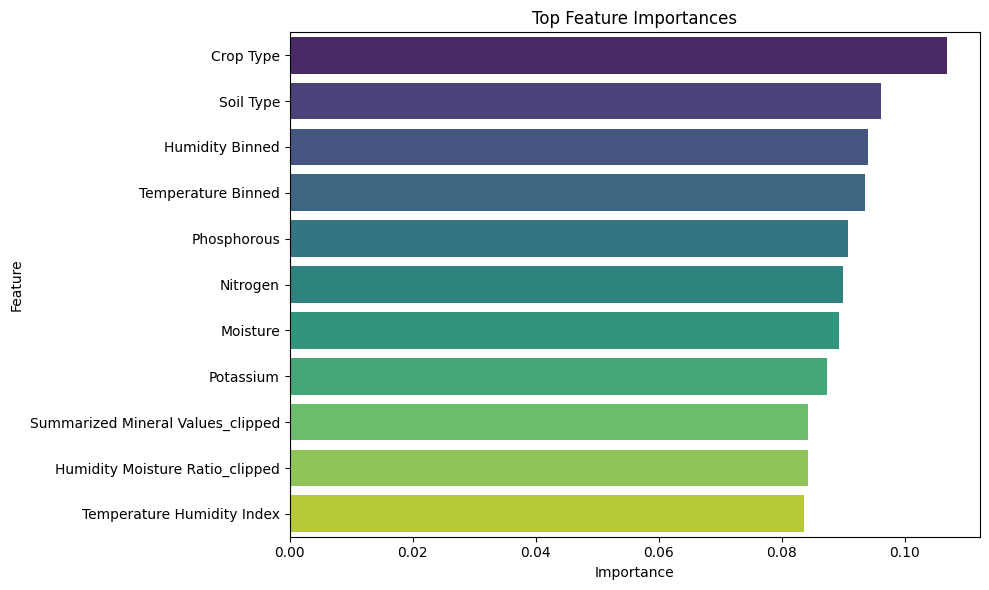

In [60]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
import seaborn as sns

importances = model_xg_multi.feature_importances_
feature_names = model_xg_multi.get_booster().feature_names

df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [62]:
rtrain_x, rtest_x, rtrain_y, rtest_y = train_test_split(full_x, full_y, test_size = 0.3, random_state = 42, stratify = full_y)
rf = RandomForestClassifier(random_state = 42)
rf.fit(rtrain_x, rtrain_y)

RandomForestClassifier(random_state=42)

In [63]:
from sklearn.metrics import accuracy_score
print(f"The accuracy score for the predictions is: {accuracy_score(rtest_y, rf.predict(rtest_x))}")

The accuracy score for the predictions is: 0.16758039215686274


In [64]:
perm_importance = permutation_importance(rf, rtest_x, rtest_y, n_repeats=30, random_state=42)

In [65]:
importance_df = pd.DataFrame({
    'feature': rtrain_x.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)
print("\n permutation feature importance: ")
print(importance_df)


 permutation feature importance: 
                              feature  importance_mean  importance_std
2                           Crop Type         0.009885        0.000646
5                         Phosphorous         0.008023        0.000725
0                            Moisture         0.006770        0.000630
3                            Nitrogen         0.006147        0.000540
1                           Soil Type         0.005475        0.000597
4                           Potassium         0.005269        0.000473
10  Summarized Mineral Values_clipped         0.002200        0.000491
9     Humidity Moisture Ratio_clipped         0.001654        0.000550
8          Temperature Humidity Index         0.001053        0.000535
6                  Temperature Binned         0.000016        0.000454
7                     Humidity Binned        -0.000180        0.000529


Conclusions:
- Binning helps improve feature importance for gradient boosted trees.
- Features engineered with domain knowledge don't add much to the score.